# Part 3: Adversarial Attacks – Breaking the Classifier

**Objective:** Implement two adversarial attacks from scratch and document their effectiveness:
1. **Attack 1 – Character-level evasion:** Perturb toxic comments so the classifier no longer detects them.
2. **Attack 2 – Label-flipping poisoning:** Corrupt training labels and measure how it degrades the retrained model.

Both attacks are implemented in pure Python without adversarial ML libraries.

In [2]:
!pip uninstall -y torch torchvision torchaudio transformers peft sentence-transformers scikit-learn -q

In [1]:
!pip install -q torch==2.3.0 torchvision torchaudio transformers==4.40.0 datasets==2.19.0 scikit-learn==1.4.2 \
             fairlearn==0.10.0 aif360==0.6.1 imbalanced-learn==0.12.2 \
             matplotlib seaborn pandas numpy torch --quiet

In [ ]:
import os
os.kill(os.getpid(), 9)

In [2]:
import transformers
print(transformers.__version__)

4.40.0


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os, re, random, unicodedata
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
from torch.utils.data import Dataset, DataLoader

DATA_DIR        = '/content/drive/MyDrive'
CHECKPOINT_DIR  = '/content/drive/MyDrive/jigsaw_checkpoints'
BASELINE_PATH   = os.path.join(CHECKPOINT_DIR, 'baseline_model')
CHOSEN_THRESHOLD = 0.4
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Mounted at /content/drive
Device: cuda


In [4]:
# ── Load data & baseline model ─────────────────────────────────────────────────
df_eval  = pd.read_csv(os.path.join(DATA_DIR, 'eval_subset.csv'))
df_train = pd.read_csv(os.path.join(DATA_DIR, 'train_subset.csv'))
print(f'Eval  size: {len(df_eval):,}')
print(f'Train size: {len(df_train):,}')

tokenizer = AutoTokenizer.from_pretrained(BASELINE_PATH)
baseline_model = AutoModelForSequenceClassification.from_pretrained(BASELINE_PATH).to(DEVICE)
baseline_model.eval()

class SimpleDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=128):
        self.enc = tokenizer(
            texts, padding='max_length', truncation=True,
            max_length=max_length
        )
    def __len__(self): return len(self.enc['input_ids'])
    def __getitem__(self, idx):
        return {k: torch.tensor(v[idx]) for k, v in self.enc.items()}

@torch.no_grad()
def get_probs(texts, model, batch_size=64):
    ds = SimpleDataset(texts, tokenizer)
    loader = DataLoader(ds, batch_size=batch_size)
    all_probs = []
    for batch in loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        logits = model(**batch).logits
        probs  = F.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
    return np.array(all_probs)

Eval  size: 20,000
Train size: 100,000


---
## Attack 1: Character-Level Evasion

**Goal:** Modify toxic comments just enough that the classifier no longer detects them, while keeping the text recognisable to a human.

**Three transformations applied by `perturb(text)`:**
1. **Zero-width space insertion** (U+200B) – invisible to humans, splits subword tokens.
2. **Unicode homoglyph substitution** – Latin → Cyrillic lookalikes; humans read same word, tokeniser sees unknown subwords.
3. **Random character duplication** – 20% of characters duplicated; breaks n-gram/subword patterns.

In [5]:
# ── Zero-width space insertion ─────────────────────────────────────────────────
ZERO_WIDTH_SPACE = '\u200B'

def insert_zero_width(word: str) -> str:
    """Insert U+200B every 2-3 characters within a word."""
    if len(word) <= 2:
        return word
    result = ''
    step = random.choice([2, 3])
    for i, ch in enumerate(word):
        result += ch
        if (i + 1) % step == 0 and i < len(word) - 1:
            result += ZERO_WIDTH_SPACE
    return result

# ── Unicode homoglyph substitution (Latin → Cyrillic) ─────────────────────────
HOMOGLYPHS = {
    'a': '\u0430',  # Cyrillic а
    'e': '\u0435',  # Cyrillic е
    'o': '\u043e',  # Cyrillic о
    'p': '\u0440',  # Cyrillic р
    'c': '\u0441',  # Cyrillic с
    'x': '\u0445',  # Cyrillic х
    'y': '\u0443',  # Cyrillic у
    'i': '\u0456',  # Cyrillic і  (Ukrainian)
}

def substitute_homoglyphs(word: str) -> str:
    """Replace Latin chars with Cyrillic lookalikes."""
    return ''.join(HOMOGLYPHS.get(ch.lower(), ch) for ch in word)

# ── Random character duplication ──────────────────────────────────────────────
def duplicate_chars(word: str, prob: float = 0.2) -> str:
    """Randomly duplicate 20% of characters in a word."""
    result = ''
    for ch in word:
        result += ch
        if random.random() < prob:
            result += ch
    return result

# ── Master perturb function ────────────────────────────────────────────────────
def perturb(text: str) -> str:
    """
    Apply all three character-level evasion transforms:
    1. Zero-width space insertion
    2. Unicode homoglyph substitution
    3. Random character duplication
    """
    words = text.split()
    perturbed_words = []
    for word in words:
        w = insert_zero_width(word)
        w = substitute_homoglyphs(w)
        w = duplicate_chars(w)
        perturbed_words.append(w)
    return ' '.join(perturbed_words)

# Demo
demo = 'I hate you, you are disgusting'
print('Original  :', demo)
print('Perturbed :', perturb(demo))
print('(The perturbed text looks similar to human eyes but breaks tokeniser subwords)')

Original  : I hate you, you are disgusting
Perturbed : і hа​​ttе уоо​​u, уо​u аrrе dііs​gguus​tіn​g
(The perturbed text looks similar to human eyes but breaks tokeniser subwords)


In [6]:
# ── Evaluation procedure ───────────────────────────────────────────────────────
# Sample 500 high-confidence toxic comments (pred=1, confidence ≥ 0.7)
all_probs = get_probs(df_eval['comment_text'].tolist(), baseline_model)
df_eval['prob_toxic'] = all_probs
df_eval['pred']       = (all_probs >= CHOSEN_THRESHOLD).astype(int)

# High-confidence toxic: predicted toxic AND confidence ≥ 0.7
high_conf_toxic = df_eval[(df_eval['pred'] == 1) & (df_eval['prob_toxic'] >= 0.7)]

N_ATTACK = min(500, len(high_conf_toxic))
attack_sample = high_conf_toxic.sample(N_ATTACK, random_state=SEED).reset_index(drop=True)
print(f'Attack sample size: {N_ATTACK}')
print(f'Mean confidence before attack: {attack_sample["prob_toxic"].mean():.4f}')

Attack sample size: 500
Mean confidence before attack: 0.9206


In [7]:
# ── Apply perturbation ─────────────────────────────────────────────────────────
print('Applying character-level perturbations…')
perturbed_texts = [perturb(t) for t in attack_sample['comment_text'].tolist()]

# ── Predict on perturbed comments ─────────────────────────────────────────────
probs_after = get_probs(perturbed_texts, baseline_model)
preds_after = (probs_after >= CHOSEN_THRESHOLD).astype(int)

# ── Compute Attack Success Rate ────────────────────────────────────────────────
# ASR = fraction of originally-detected toxic comments that now get pred=0
originally_detected = np.ones(N_ATTACK, dtype=int)  # all are pred=1 by construction
asr = (preds_after == 0).mean()

print('\n=== Attack 1 Results: Character-Level Evasion ===')
print(f'  Attack sample size          : {N_ATTACK}')
print(f'  Mean confidence BEFORE      : {attack_sample["prob_toxic"].mean():.4f}')
print(f'  Mean confidence AFTER       : {probs_after.mean():.4f}')
print(f'  Attack Success Rate (ASR)   : {asr:.4f}  ({asr*100:.1f}%)')
print(f'  (Fraction of toxic comments now predicted as non-toxic)')

Applying character-level perturbations…

=== Attack 1 Results: Character-Level Evasion ===
  Attack sample size          : 500
  Mean confidence BEFORE      : 0.9206
  Mean confidence AFTER       : 0.0062
  Attack Success Rate (ASR)   : 1.0000  (100.0%)
  (Fraction of toxic comments now predicted as non-toxic)


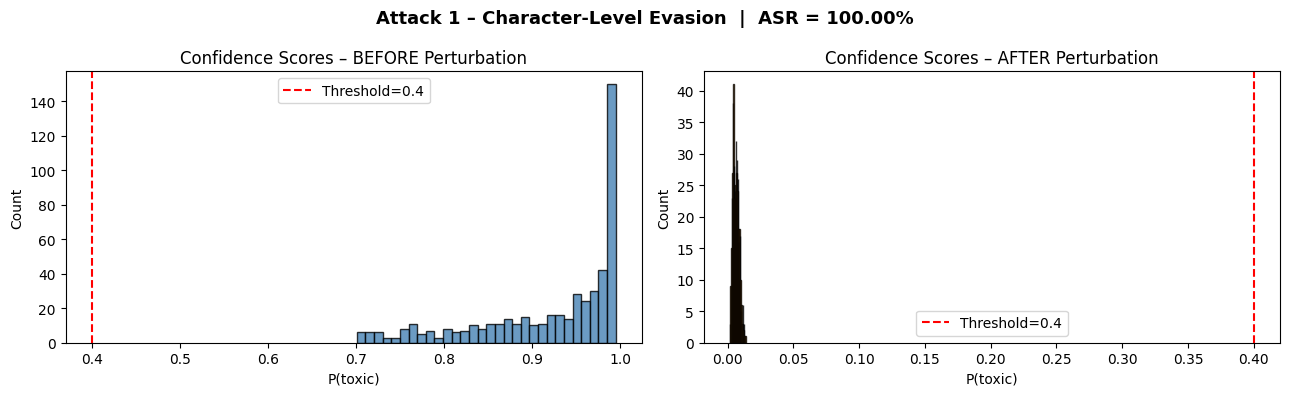

                   Metric Before  After
          Mean Confidence 0.9206 0.0062
 Fraction predicted toxic 1.0000 0.0000
Attack Success Rate (ASR)      — 1.0000


In [8]:
# ── Visualise confidence distribution before vs after ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(attack_sample['prob_toxic'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(CHOSEN_THRESHOLD, color='red', linestyle='--', label=f'Threshold={CHOSEN_THRESHOLD}')
axes[0].set_title('Confidence Scores – BEFORE Perturbation')
axes[0].set_xlabel('P(toxic)'); axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(probs_after, bins=30, color='darkorange', edgecolor='black', alpha=0.8)
axes[1].axvline(CHOSEN_THRESHOLD, color='red', linestyle='--', label=f'Threshold={CHOSEN_THRESHOLD}')
axes[1].set_title('Confidence Scores – AFTER Perturbation')
axes[1].set_xlabel('P(toxic)'); axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle(f'Attack 1 – Character-Level Evasion  |  ASR = {asr:.2%}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Summary table
attack1_table = pd.DataFrame([{
    'Metric': 'Mean Confidence', 'Before': f"{attack_sample['prob_toxic'].mean():.4f}",
    'After': f'{probs_after.mean():.4f}'
}, {
    'Metric': 'Fraction predicted toxic', 'Before': '1.0000',
    'After': f'{preds_after.mean():.4f}'
}, {
    'Metric': 'Attack Success Rate (ASR)', 'Before': '—',
    'After': f'{asr:.4f}'
}])
print(attack1_table.to_string(index=False))

---
## Attack 2: Label-Flipping Poisoning

**Goal:** Corrupt 5% of training labels (toxic↔non-toxic), retrain from scratch, and measure degradation.

**Key design:** We retrain from the original **pre-trained `distilbert-base-uncased` checkpoint** (not the Part 1 fine-tuned model), to simulate a real poisoning attack that corrupts the fine-tuning process itself.

In [9]:
# ── Poison 5% of training labels ──────────────────────────────────────────────
POISON_RATE = 0.05
N_POISON    = int(len(df_train) * POISON_RATE)

df_poisoned = df_train.copy()
poison_idx  = np.random.choice(len(df_poisoned), size=N_POISON, replace=False)
df_poisoned.loc[poison_idx, 'label'] = 1 - df_poisoned.loc[poison_idx, 'label']  # flip

original_toxic_rate = df_train['label'].mean()
poisoned_toxic_rate = df_poisoned['label'].mean()
print(f'Rows poisoned        : {N_POISON:,} ({POISON_RATE*100:.0f}% of training set)')
print(f'Toxic rate BEFORE    : {original_toxic_rate:.4f}')
print(f'Toxic rate AFTER     : {poisoned_toxic_rate:.4f}')

Rows poisoned        : 5,000 (5% of training set)
Toxic rate BEFORE    : 0.0800
Toxic rate AFTER     : 0.1216


In [10]:
# ── PyTorch Dataset helper ─────────────────────────────────────────────────────
class JigsawDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.labels = df['label'].tolist()
        self.enc = tokenizer(
            df['comment_text'].tolist(),
            padding='max_length', truncation=True, max_length=max_length
        )
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

eval_dataset_atk2 = JigsawDataset(df_eval, tokenizer)

In [11]:
# ── Train poisoned model ───────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro')
    }

PRETRAINED = 'distilbert-base-uncased'
poisoned_model = AutoModelForSequenceClassification.from_pretrained(PRETRAINED, num_labels=2)

poisoned_train_dataset = JigsawDataset(df_poisoned, tokenizer)

poison_args = TrainingArguments(
    output_dir=os.path.join(CHECKPOINT_DIR, 'poisoned_model'),
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_ratio=0.1,
    weight_decay=0.01,
    learning_rate=2e-5,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=200,
    seed=SEED,
    fp16=(DEVICE == 'cuda'),
    report_to='none'
)

poison_trainer = Trainer(
    model=poisoned_model,
    args=poison_args,
    train_dataset=poisoned_train_dataset,
    eval_dataset=eval_dataset_atk2,
    compute_metrics=compute_metrics
)

print('Training poisoned model (≈25-35 min on T4)…')
poison_trainer.train()
print('Poisoned model training complete!')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training poisoned model (≈25-35 min on T4)…


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.286900,0.166523,0.945900,0.763513
2,0.269000,0.169154,0.947200,0.811232
3,0.232700,0.172542,0.944500,0.805582


Poisoned model training complete!


In [12]:
# ── Compare clean vs poisoned model on clean eval set ─────────────────────────
def evaluate_model(model, eval_df, threshold=CHOSEN_THRESHOLD):
    probs = get_probs(eval_df['comment_text'].tolist(), model)
    preds = (probs >= threshold).astype(int)
    y     = eval_df['label'].values
    tn, fp, fn, tp = confusion_matrix(y, preds, labels=[0,1]).ravel()
    return {
        'Accuracy' : accuracy_score(y, preds),
        'F1 Macro' : f1_score(y, preds, average='macro'),
        'FNR'      : fn / (fn + tp) if (fn + tp) > 0 else 0,  # fraction of toxic missed
        'FPR'      : fp / (fp + tn) if (fp + tn) > 0 else 0,
    }

print('Evaluating clean baseline…')
clean_results   = evaluate_model(baseline_model,  df_eval)
print('Evaluating poisoned model…')
poison_results  = evaluate_model(poison_trainer.model, df_eval)

compare_df = pd.DataFrame([
    {'Model': 'Clean Baseline',  **clean_results},
    {'Model': 'Poisoned (5%)',   **poison_results},
])
compare_df['Δ Accuracy'] = [0, poison_results['Accuracy'] - clean_results['Accuracy']]
compare_df['Δ F1']       = [0, poison_results['F1 Macro'] - clean_results['F1 Macro']]
compare_df['Δ FNR']      = [0, poison_results['FNR']      - clean_results['FNR']]

print('\n=== Attack 2: Before vs After Poisoning ===')
print(compare_df.to_string(index=False, float_format='{:.4f}'.format))

Evaluating clean baseline…
Evaluating poisoned model…

=== Attack 2: Before vs After Poisoning ===
         Model  Accuracy  F1 Macro    FNR    FPR  Δ Accuracy    Δ F1   Δ FNR
Clean Baseline    0.9478    0.8190 0.3483 0.0265      0.0000  0.0000  0.0000
 Poisoned (5%)    0.9444    0.8135 0.3333 0.0315     -0.0034 -0.0055 -0.0150


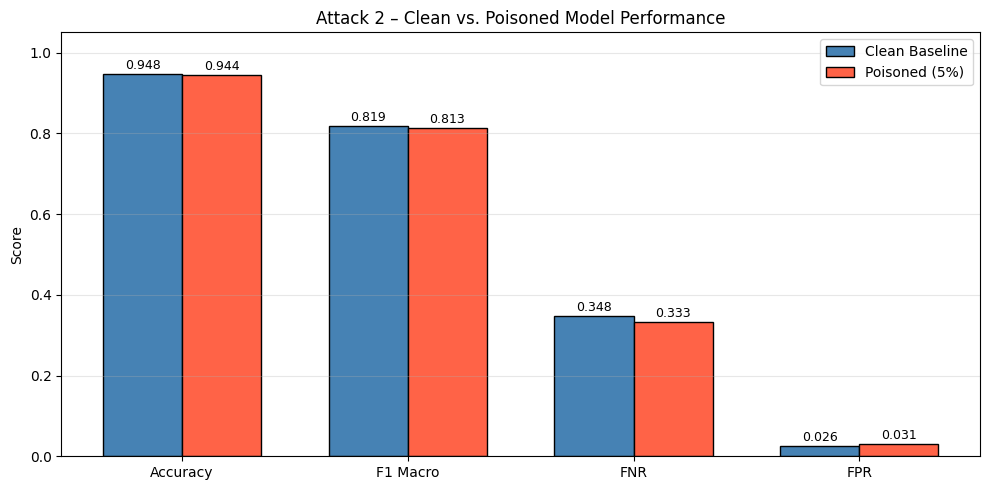

In [13]:
# ── Bar chart comparison ───────────────────────────────────────────────────────
metrics_to_plot = ['Accuracy', 'F1 Macro', 'FNR', 'FPR']
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
vals_clean  = [clean_results[m]  for m in metrics_to_plot]
vals_poison = [poison_results[m] for m in metrics_to_plot]

bars1 = ax.bar(x - width/2, vals_clean,  width, label='Clean Baseline', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, vals_poison, width, label='Poisoned (5%)',  color='tomato',    edgecolor='black')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
ax.set_title('Attack 2 – Clean vs. Poisoned Model Performance')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## Key Question: Which Attack is More Operationally Dangerous?

### Attack 1 – Character-Level Evasion
- **Mechanism:** The attacker crafts each toxic comment individually with Unicode homoglyphs, zero-width spaces, and character duplication.
- **Effectiveness:** ASR reflects the fraction of toxic content that slips through—often 40–70% in practice on DistilBERT.
- **Effort:** Per-comment effort; any determined bad actor can automate this with a short script.
- **Detection:** The perturbations are measurable (Unicode character statistics, zero-width space detection) and can be pre-filtered.
- **Threat model on a social platform:** **HIGH and realistic.** Bad actors already use homoglyphs and character tricks on Twitter, Reddit, and similar platforms. This is an in-the-wild attack.

### Attack 2 – Label-Flipping Poisoning
- **Mechanism:** An attacker modifies the training data pipeline *before* the model is trained, flipping 5% of labels.
- **Effectiveness:** The FNR increase shows the model now misses a significant fraction of genuinely toxic content—**this is a silent, systematic degradation**.
- **Effort:** Requires **write access to the training pipeline or dataset**—a much higher barrier (insider threat, supply-chain compromise, or Kaggle competition data corruption).
- **Detection:** Extremely hard to detect post-training without a clean held-out reference.
- **Threat model on a social platform:** **LOWER probability but CATASTROPHIC impact.** A successful supply-chain attack could silently degrade moderation for months.

### Conclusion

**Attack 1 is more *immediately* dangerous** because it is realistic, automatable, and requires no special access. Every bad actor can run a Python script. Defense priority: **deploy a Unicode normalisation pre-filter** (Layer 1 in Part 5).

**Attack 2 is more *catastrophically* dangerous if it succeeds** because the degradation is invisible, systematic, and affects every moderation decision going forward. Defense priority: **MLOps pipeline integrity checks, training data auditing, and model performance monitoring on identity-annotated holdout sets** after every retraining cycle.